## Importamos los módulos y datos

In [1]:
import pandas as pd
import hvplot.pandas
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
from func import procesa_datos

tzinfo_madrid = ZoneInfo("Europe/Madrid")

primary_cols = [
    'date',
    'precio_spot_diario_Espana',
    'precio_spot_intradiario3_Espana',
    'dem_prev_diaria_6',
    'gen_prev_eolica_6',
    'gen_prev_fotov_6',
    'spread_ida3_spot',
]


df = procesa_datos(cols_to_keep=primary_cols)
df["cls_spread_ida3_spot"] = np.where(df["spread_ida3_spot"] >=0, 1, -1)

C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida1_spot"] = df["precio_spot_intradiario1_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "spread_ida2_spot"] = df["precio_spot_intradiario2_Espana"] - df["precio_spot_diario_Espana"]
C:\Users\Usuario\Desktop\Master UGR\TFM\src\func.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is us

## Procesado de datos, feature eng., train y test.

In [2]:
## Creamos variables nuevas
from func import crear_lags_horarios
df = crear_lags_horarios(df, ["spread_ida3_spot", "precio_spot_diario_Espana", "precio_spot_intradiario3_Espana"], [24, 48, 72]).dropna()

## Fechas de entrenamiento, validación y test
train_from, train_to = datetime(2025, 11, 5, tzinfo=tzinfo_madrid),  datetime(2026, 2, 28, 23, 45, tzinfo=tzinfo_madrid)
test_from, test_to = datetime(2026, 4, 1, tzinfo=tzinfo_madrid), datetime(2026, 5, 31, 23, 45, tzinfo=tzinfo_madrid)

## columnas de entrenamiento
train_cols = [
    'dem_prev_diaria_6',
    'gen_prev_eolica_6',
    'gen_prev_fotov_6',
    'precio_spot_diario_Espana_lag_24h',
    'precio_spot_diario_Espana_lag_48h',
    'precio_spot_diario_Espana_lag_72h',
    'precio_spot_intradiario3_Espana_lag_24h',
    'precio_spot_intradiario3_Espana_lag_48h',
    'precio_spot_intradiario3_Espana_lag_72h',
    'spread_ida3_spot_lag_24h',
    'spread_ida3_spot_lag_48h',
    'spread_ida3_spot_lag_72h'
]
tgt_col = "spread_ida3_spot"
tgt_col_cls = "cls_spread_ida3_spot"

## dividimos los datasets reg
X_train, y_train = df.loc[train_from:train_to, train_cols], df.loc[train_from:train_to, tgt_col]
X_test, y_test =df.loc[test_from:test_to, train_cols], df.loc[test_from:test_to, tgt_col]

## dividimos los datasets reg
_, y_train_cls = df.loc[train_from:train_to, train_cols], df.loc[train_from:train_to, tgt_col_cls]
_, y_test_cls =df.loc[test_from:test_to, train_cols], df.loc[test_from:test_to, tgt_col_cls]

## Modelos y problema de optimización

Hay que hacer una predicción por día con su correspondiente problema de optimización

In [3]:
import numpy as np

def optimizador(pred_spread,
                max_ops=20,
                max_buy=10,
                max_sell=10,
                threshold=10.0):
    """
    Devuelve un vector w ∈ {-1,0,1}
    """

    pred_spread = np.asarray(pred_spread)

    w = np.zeros(len(pred_spread))

    # -------- Compras --------
    buy_idx = np.where(pred_spread >= threshold)[0]

    if len(buy_idx) > 0:
        buy_sorted = buy_idx[np.argsort(pred_spread[buy_idx])[::-1]]
        buy_selected = buy_sorted[:max_buy]

        w[buy_selected] = 1

    # -------- Ventas --------
    sell_idx = np.where(pred_spread <= -threshold)[0]

    if len(sell_idx) > 0:
        sell_sorted = sell_idx[np.argsort(pred_spread[sell_idx])]
        sell_selected = sell_sorted[:max_sell]

        w[sell_selected] = -1

    # -------- Máximo número total de operaciones --------
    if np.sum(w != 0) > max_ops:

        idx = np.where(w != 0)[0]

        importancia = np.abs(pred_spread[idx])

        mejores = idx[np.argsort(importancia)[::-1][:max_ops]]

        w[:] = 0
        w[mejores] = np.sign(pred_spread[mejores])

    return -w

A continuación se detallan las pruebas que vamos a hacer:

- Regresión Ridge.
- Random Forest.
- Random Forest como problema de clasificación.
- CatBoost.
- Regresión lineal con la función de pérdida Tangente Hiperbólica.
- Regresión lineal con la función de pérdida Log-Sigmoid.
- Regresión lineal con la función de pérdida Exponencial PNL.
- CatBoost con la función de pérdida Tangente Hiperbólica.
- CatBoost con la función de pérdida Log-Sigmoid.
- CatBoost con la función de pérdida Exponencial PNL.
- SPO.

In [4]:
from func import get_ridge_model, get_rf_model, get_catboost_model, get_clsrf_model, get_lr_model
from pnl_custom_losses import  TanhPnLLoss, LogSigmoidPnLLoss, ExpoPnLLoss


reg_ridge = get_ridge_model()
rf = get_rf_model()
cls_rf = get_clsrf_model()
cb = get_catboost_model()
lr_tanh = get_lr_model(loss_function="TanhPnLLoss")
lr_logsigmoid = get_lr_model(loss_function="LogSigmoidPnLLoss")
lr_exp_pnl = get_lr_model(loss_function="ExpoPnLLoss") # alpha=0.5
cb_tanh = get_catboost_model(loss_function="TanhPnLLoss") 
cb_logsigmoid = get_catboost_model(loss_function="LogSigmoidPnLLoss")
cb_exp_pnl = get_catboost_model(loss_function="ExpoPnLLoss") # alpha=0.5

_ = reg_ridge.fit(X_train, y_train)
_ = rf.fit(X_train, y_train)
_ = cls_rf.fit(X_train, y_train_cls)
_ = cb.fit(X_train, y_train)
_ = lr_tanh.fit(X_train, y_train)
_ = lr_logsigmoid.fit(X_train, y_train)
_ = lr_exp_pnl.fit(X_train, y_train)
_ = cb_tanh.fit(X_train, y_train) 
_ = cb_logsigmoid.fit(X_train, y_train)
_ = cb_exp_pnl.fit(X_train, y_train)

C:\Users\Usuario\anaconda3\envs\itachi\Lib\site-packages\catboost\core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
C:\Users\Usuario\Desktop\Master UGR\TFM\src\pnl_custom_losses.py:45: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + np.exp(-x)),
C:\Users\Usuario\Desktop\Master UGR\TFM\src\pnl_custom_losses.py:46: RuntimeWarning: overflow encountered in exp
  np.exp(x) / (1.0 + np.exp(x)))
C:\Users\Usuario\Desktop\Master UGR\TFM\src\pnl_custom_losses.py:46: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(x) / (1.0 + np.exp(x)))


In [5]:
from linearSPO import SPOPlusLinearRegression, format_data_to_SPO
from sklearn.preprocessing import StandardScaler

## Entrenamiento SPO
X_train_spo, y_train_spo = format_data_to_SPO(X_train, y_train)
X_test_spo, y_test_spo = format_data_to_SPO(X_test, y_test)

std_scaler = StandardScaler()
std_scaler.fit(X_train_spo)

X_train_spo = std_scaler.transform(X_train_spo)
X_test_spo = std_scaler.transform(X_test_spo)

modelo = SPOPlusLinearRegression(
    learning_rate=1e-3,
    epochs=300
)

modelo.fit(X_train_spo, y_train_spo, optimizador)

Epoch   1   Loss=571.6464
Epoch   2   Loss=568.7841
Epoch   3   Loss=567.6746
Epoch   4   Loss=566.4968
Epoch   5   Loss=565.4197
Epoch   6   Loss=564.7041
Epoch   7   Loss=563.9991
Epoch   8   Loss=563.2177
Epoch   9   Loss=561.9318
Epoch  10   Loss=560.9277
Epoch  11   Loss=560.0221
Epoch  12   Loss=559.0403
Epoch  13   Loss=558.6684
Epoch  14   Loss=557.7038
Epoch  15   Loss=557.0077
Epoch  16   Loss=556.2368
Epoch  17   Loss=555.3869
Epoch  18   Loss=554.8033
Epoch  19   Loss=554.1478
Epoch  20   Loss=553.6784
Epoch  21   Loss=552.7041
Epoch  22   Loss=551.7365
Epoch  23   Loss=550.8657
Epoch  24   Loss=550.2596
Epoch  25   Loss=549.7500
Epoch  26   Loss=548.8269
Epoch  27   Loss=548.2599
Epoch  28   Loss=547.6127
Epoch  29   Loss=546.7978
Epoch  30   Loss=546.1677
Epoch  31   Loss=545.2873
Epoch  32   Loss=544.7589
Epoch  33   Loss=543.9817
Epoch  34   Loss=543.3895
Epoch  35   Loss=542.5471
Epoch  36   Loss=541.7976
Epoch  37   Loss=541.3962
Epoch  38   Loss=540.5671
Epoch  39   

## Predicción

In [6]:
unique_dates = np.unique(X_test.index.date)

In [7]:
def pred_w(model, X, optimizador, name, is_cls=False):
    preds = model.predict(X)
    if is_cls:
        w_preds = model.predict(X)
    else:
        w_preds = -optimizador(preds)
    return {f"pred_{name}": preds, f"w_{name}": w_preds}

In [12]:
df_results = pd.DataFrame()
df_results_spo = pd.DataFrame()


model_names_reg = {
    "Ridge": reg_ridge,
    "RF": rf,
    "CatBoost": cb,
    "LR_tanh": lr_tanh,
    "LR_logsigmoid": lr_logsigmoid,
    "LR_exp_pnl": lr_exp_pnl,
    "CB_tanh": cb_tanh,
    "CB_logsigmoid": cb_logsigmoid,
    "CB_exp_pnl": cb_exp_pnl,   
}

model_names_cls = {}

# Predecimos modelos ML normales
for dt in unique_dates:
    X_aux = X_test[X_test.index.date==dt]
    idx = X_aux.index
    
    dcc = {"date": idx}

    for name, model in model_names_reg.items():
        dcc |= pred_w(model, X_aux, optimizador, name)

    for name, model in model_names_cls.items():
        dcc |= pred_w(model, X_aux, optimizador, name, is_cls=True)

    res = pd.DataFrame(dcc)
    df_results = pd.concat([df_results, res], ignore_index=True)
    
## Predecimos SPO
for i in range(X_test_spo.shape[0]):
    y_pred_spo = modelo.predict(X_test_spo[i])
    w_spo = -optimizador(y_pred_spo)

    res = pd.DataFrame({"y_pred_spo": y_pred_spo, "w_spo": w_spo})
    df_results_spo = pd.concat([df_results_spo, res], ignore_index=True)

In [13]:
df_results = df_results.set_index("date")
df_results["y_pred_spo"] = df_results_spo["y_pred_spo"].values
df_results["w_spo"] = df_results_spo["w_spo"].values
df_results[tgt_col] = y_test

w_cols = [f"w_{col}" for col in list(model_names_reg.keys()) + list(model_names_cls.keys())]
w_cols = w_cols + ["w_spo"]

for col in w_cols:
    df_results[f"pnl_{col}"] =  df_results[col] * df_results[tgt_col]

In [14]:
pnl_cols = [f"pnl_{col}" for col in w_cols]

df_results[pnl_cols].sum()

pnl_w_Ridge               0.00
pnl_w_RF                195.13
pnl_w_CatBoost          696.66
pnl_w_LR_tanh           299.04
pnl_w_LR_logsigmoid    -465.57
pnl_w_LR_exp_pnl       -375.20
pnl_w_CB_tanh           -26.03
pnl_w_CB_logsigmoid    -710.67
pnl_w_CB_exp_pnl        -22.55
pnl_w_spo              1239.64
dtype: float64

In [15]:
df_results[pnl_cols] = df_results[pnl_cols].cumsum()

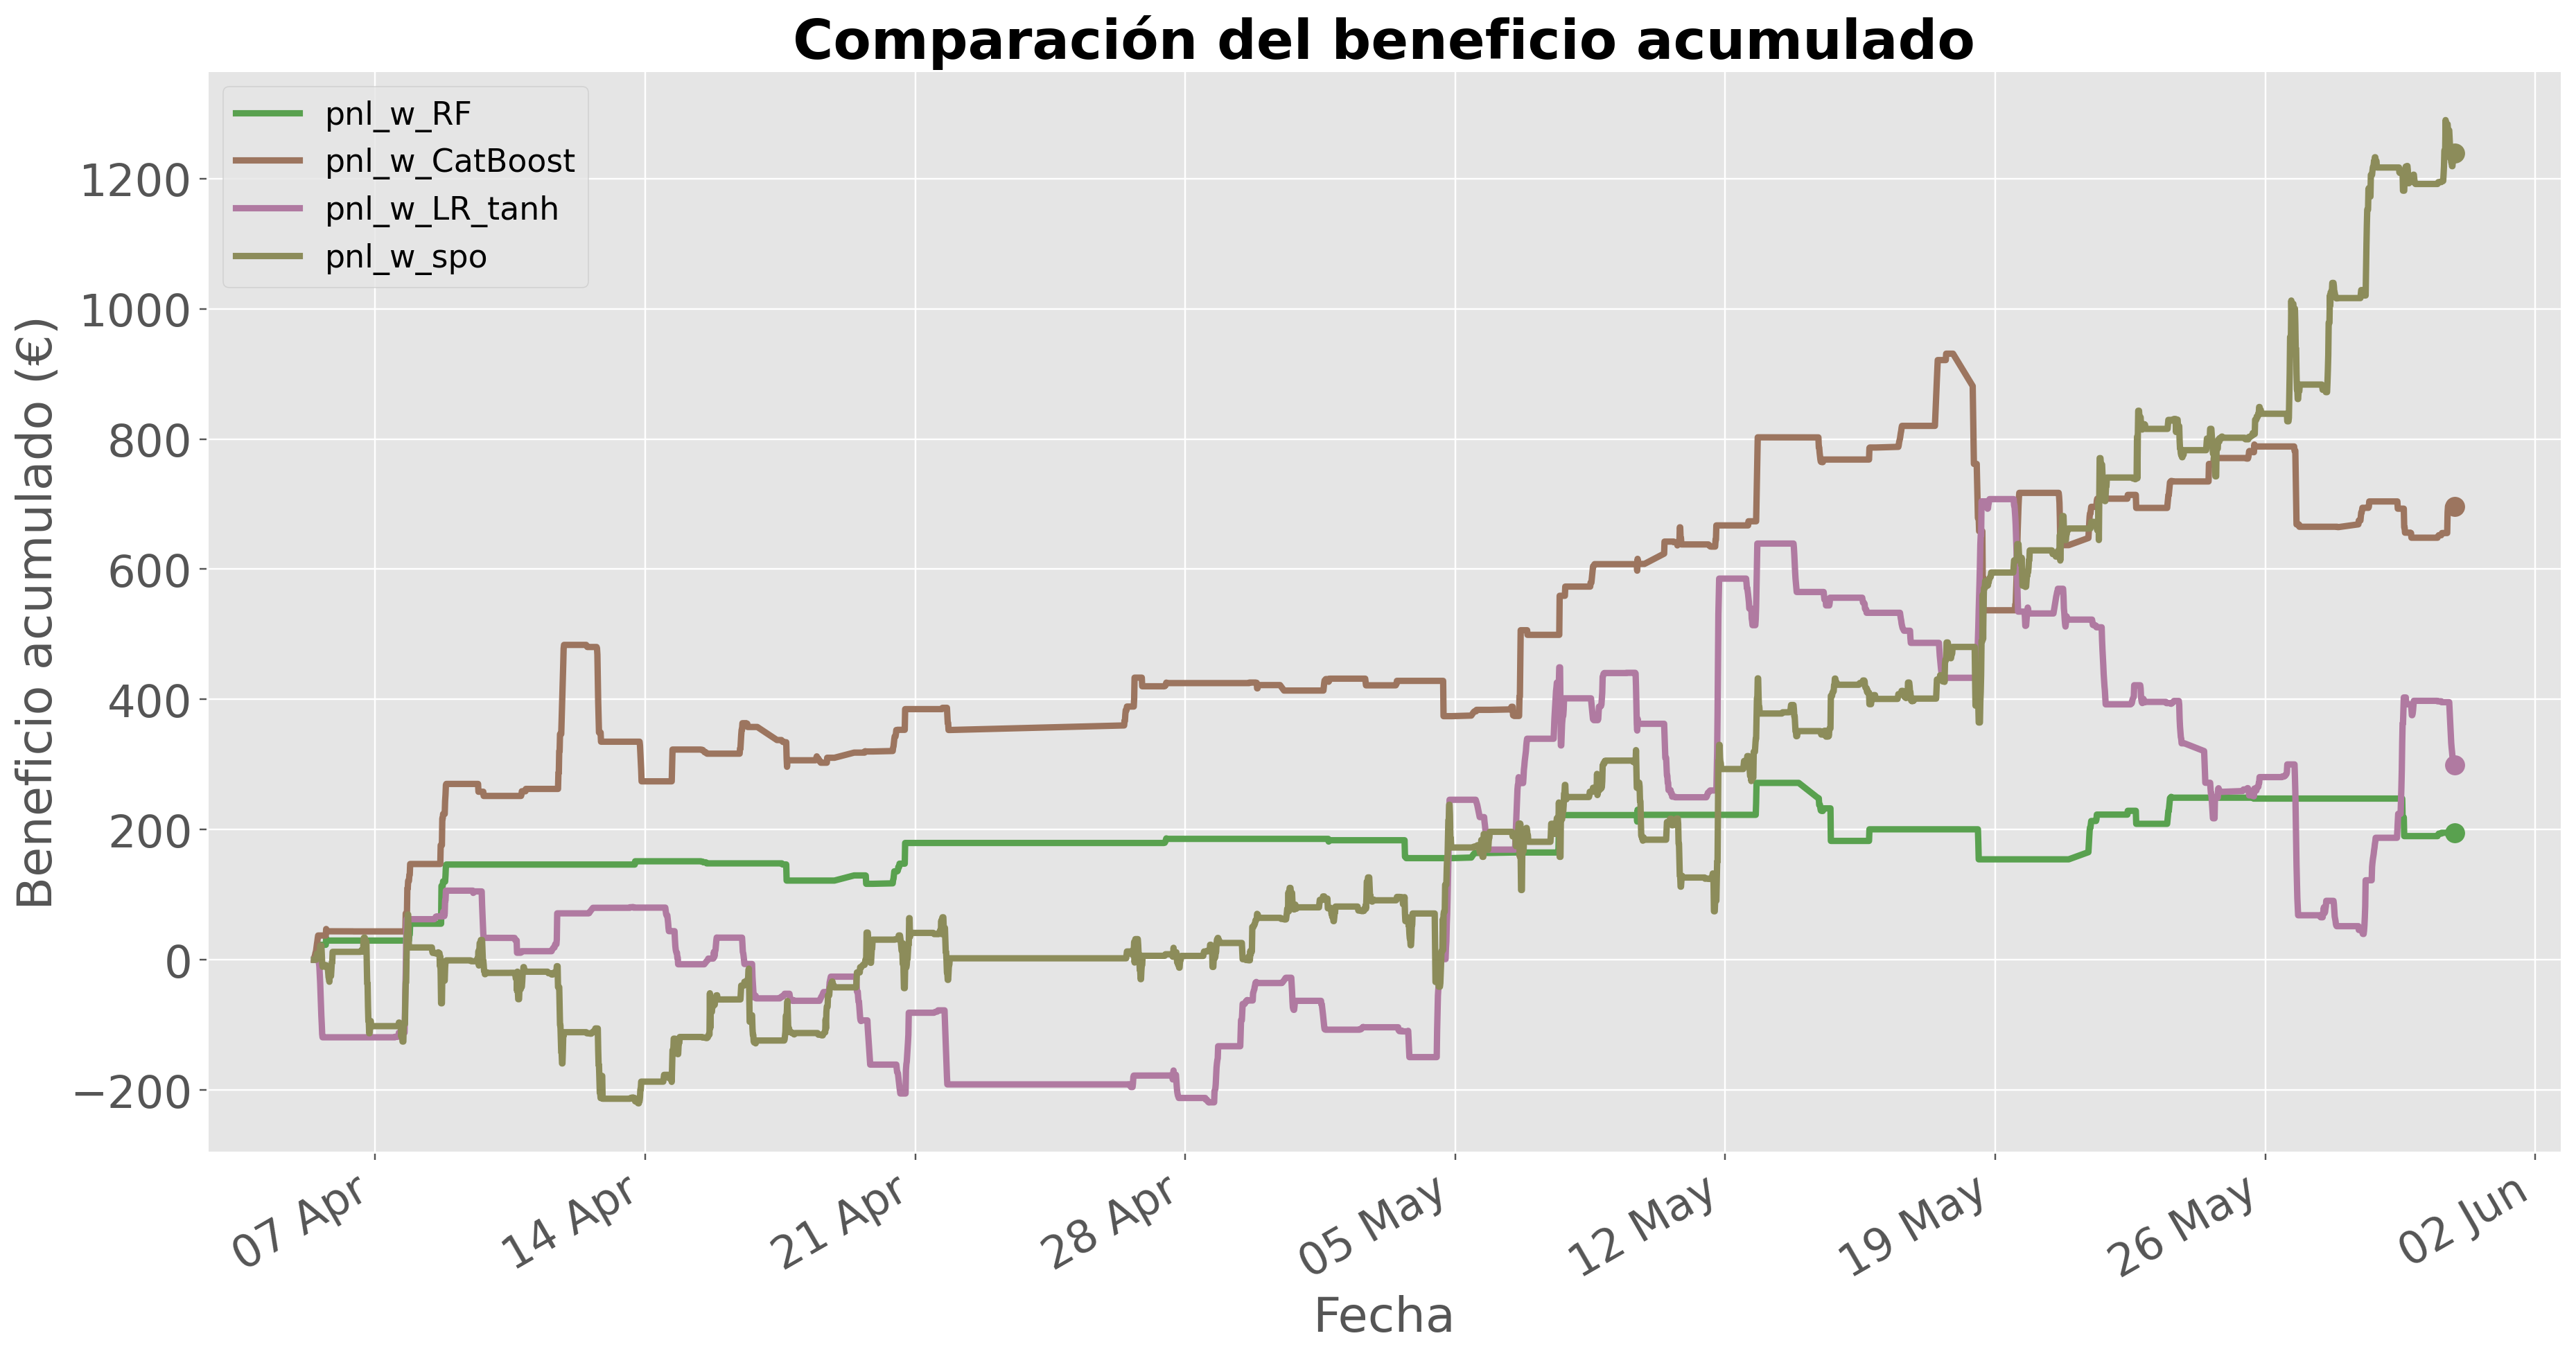

In [20]:
from plots import get_pnl_graph

colores = {
    # "pnl_w_Ridge": "#4E79A7",
    "pnl_w_RF": "#59A14F",
    "pnl_w_CatBoost": "#9C755F",
    "pnl_w_LR_tanh": "#B07AA1",
    # "pnl_w_LR_logsigmoid": "#F28E2B",
    # "pnl_w_LR_exp_pnl": "#76B7B2",
    # "pnl_w_CB_tanh":  "#E15759",
    # "pnl_w_CB_logsigmoid": "#BAB0AC",
    # "pnl_w_CB_exp_pnl": "#7F7F7F",
    # "pnl_w_RF_cls": "#86BCB6",
    "pnl_w_spo": "#8C8C5A",
}

fig, ax = get_pnl_graph(df_results, colores, list(colores.keys()), save_path="pnl_acum_ida3_restricciones.png")

# plt.show()

In [13]:
pred_cols = [f"pred_{col}" for col in list(model_names_reg.keys())] + ["y_pred_spo"]

In [14]:
from func import get_metrics_regression
get_metrics_regression(df_results, tgt_col, pred_cols)

,Modelo,MAE,MSE,R2
0,pred_Ridge,9.778667,228.575038,-0.035376
1,pred_RF,10.487320,247.520671,-0.121194
2,pred_CatBoost,11.798901,281.713919,-0.276079
3,pred_LR_tanh,101.990550,14398.114368,-64.219117
4,pred_LR_logsigmoid,12.877021,284.931718,-0.290655
5,pred_LR_exp_pnl,12.440418,270.671435,-0.226060
6,y_pred_spo,81.782440,13092.397586,-58.304614


In [ ]:
get_metrics_clasification(df_results, tgt_col, pred_cols)